In [225]:
# import
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from matplotlib.gridspec import GridSpec


In [226]:
# Experimental values

# Select parameter set: 0 = current SW, 1 = current DD, 2 = optimistic, 3 = very optimistic, 4 = Welinq
par = 1

# ------------------------------
# Quantum Memory Parameters
# ------------------------------

eta_AFC0 = [0.3, 0.6, 0.7, 0.9, 0.9][par]       # AFC efficiency at zero delay
eta_CP = [0.7, 0.8, 0.9, 0.98, 1][par]          # Control pulse efficiency
eta_m0 = eta_AFC0 * eta_CP * eta_CP             # Memory efficiency at zero delay

cycle_mem = 1                                   # Memory cycle duration [s]
prep_mem = [0.35, 0.3, 0.25, 0.2, 0.1][par]     # Time needed to reinitialize memory [s]
eta_duty_mem = 1 - prep_mem / cycle_mem         # Duty cycle of the memory

T_acceptance = 30e-6                            # Time window for entering AFC before spin wave storage [s]
lat = 150e-6                                    # Memory latency after a success [s]

NF = [8.2e-4, 8.2e-4, 6e-4, 5e-4, 5e-4][par]    # Noise floor
tau_eff = [2e-3, 4e-3, 8e-3, 20e-3, 20e-3][par] # Effective memory lifetime with DD [s]

# ------------------------------
# SPDC Source Parameters
# ------------------------------
eta_h = [0.3, 0.5, 0.6, 0.8, 0.6][par]           # Heralding efficiency
P = 2                                        # SPDC pump power [mW]
a = 6                                           # g^2(0) model parameter
bright = 1_700_000                              # Brightness [counts/s/mW]
M = 15                                          # Multimode scaling factor
Rid0 = 2 * bright / M                           # Heralding rate at source output [Hz/mW]
g2 = 1 + a / P                                  # Cross-correlation function
eta_duty_chopper = [20/33, 20/33, 22/33, 25/33, 1][par] # Duty cycle of the chopper (locking)
eta_phase_stab = 3/4                       # Phase stabilization time divided by time of phase stab + time of photon generation

# ------------------------------
# Sync & Timing Capabilities
# ------------------------------
T_max = tau_eff * 1                                # Max waiting time for a match [s]

# ------------------------------
# Optical Transmission Efficiencies
# ------------------------------
eta_T1 = [0.6, 0.7, 0.8, 0.95, 1][par]          # Source-to-memory
eta_T2 = [0.5, 0.6, 0.8, 0.90, 0.9][par]        # Memory-to-filter
eta_T3 = [0.7, 0.8, 0.90, 0.95, 1][par]         # Filter-to-fiber
eta_path = eta_T1 * eta_T2 * eta_T3                      # Total path efficiency

# ------------------------------
# Detection and Visibility
# ------------------------------
Vphase = [0.9, 0.95, 0.97, 0.96, 0.96][par]     # Phase visibility
etaOv = [0.9, 0.9, 0.95, 0.99, 0.99][par]       # Mode overlap

eta_d = [0.85, 0.85, 0.90, 0.95, 0.9][par]       # Detector efficiency


# ------------------------------
# Fiber Channel Specs
# ------------------------------
L = 50                                      # Fiber length [km]
alpha = 0.2                                 # Attenuation [dB/km]
fib = 10 ** (-alpha * L / 10)               # Fiber transmission

c = 299_792.458                             # Speed of light [km/s]
n = 1.5                                     # Refractive index of fiber
T_L = ( L * n) / c                          # one way-trip communication time [s]

In [227]:
params = {
    "eta_AFC0": eta_AFC0,
    "eta_CP": eta_CP,
    "cycle_mem": cycle_mem,
    "prep_mem": prep_mem,
    "T_acceptance": T_acceptance,
    "lat": lat,
    "NF": NF,
    "tau_eff": tau_eff,
    "eta_h": eta_h,
    "P": P,
    "a": a,
    "bright": bright,
    "M": M,
    "eta_duty_chopper": eta_duty_chopper,
    "eta_phase_stab": eta_phase_stab,
    "T_max": T_max,
    "eta_T1": eta_T1,
    "eta_T2": eta_T2,
    "eta_T3": eta_T3,
    "Vphase": Vphase,
    "etaOv": etaOv,
    "eta_d": eta_d,
    "L": L,
    "alpha": alpha,
    "c": c,
    "n": n,
}

In [228]:
class DoubleChainLink:
    def __init__(self, params, memory_modes = 1,print_rate = False):
        self.params = SimpleNamespace(**params)
        self.calculate_params()
        self.print_rate = print_rate
        self.memory_modes = memory_modes

    def calculate_params(self):
        """Calculate parameters that depend on other parameters."""
        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.Rid0 = 2 * self.params.bright / self.params.M
        self.params.g2 = 1 + self.params.a / self.params.P
        self.params.T_max = self.params.tau_eff * 0.5
        self.params.eta_path = self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3
        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c

    # time dependent functions

    def efficiency(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw(self, t):
        """Cross-correlation function as a function of storage time."""
        return 1 + self.params.eta_h * self.efficiency(t) * self.params.eta_path * self.params.eta_d  / (self.params.eta_h * self.efficiency(t) * self.params.eta_path * self.params.eta_d / self.params.g2 + self.params.NF)

    def V(self, t):
        """Visibility as a function of storage time."""
        return (self.g2_sw(t) - 1) / (self.g2_sw(t) + 1) * self.params.Vphase * self.params.etaOv

    def p10(self, t):
        """Probability to detect a photon on the left of the link, and no photon on the right, conditioned on idler detection."""
        return self.efficiency(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2

    def p11(self, t):
        """Probability to detect a photon on the left of the link, and a photon on the right, conditioned on idler detection."""
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def q_pop(self, t):
        """ Part of the density matrix population in the |10><10| and |01><01| subspace, conditioned on idler detection."""
        return (2 * self.p10(t))/(2 * self.p10(t) + self.p11(t))

    def F_k_(self, k):
        """ Fidelity of the state in the case where the first ready event happens at round k, i.e. after a storage time of 2*k*T_L."""
        t = 2 * k * self.params.T_L
        return self.q_pop(0) * self.q_pop(t) * (1 + self.V(0) * self.V(t)) / 2

    def w_(self, k):
        return self.p**2 if k == 0 else 2 * self.p**2 * self.q**k

    def get_rates(self):
        self.N = np.floor(self.params.T_max / 2 / self.params.T_L)                  # Number of rounds before giving up
        self.Gamma_1 = self.params.Rid0 * self.params.P * self.params.fib * self.params.eta_d * 2     # heralding rate of idlers in central station
        self.p = 1 - np.exp(- self.Gamma_1 * self.params.T_acceptance)       # Probability of at least one heralding event in T_acceptance
        self.q = 1 - self.p                                                              # Probability of no heralding event in T_acceptance
        
        if self.memory_modes == 1:
            self.p_ready_conditioned_non_empty = self.p ** 2 / (1 - self.q**2) + 2*self.p*self.q/(1 - self.q**2) * (1 - self.q**self.N)             # Probability of being ready given a non-empty queue
            self.p_ready = self.p_ready_conditioned_non_empty * (1 - self.q**2)

                # average time of a cycle
            self.n_first = 1 / (1-self.q**2)                      # Average number of rounds until first attempt 
            self.n_extra = (1 - self.q**self.N) / self.p                    # Extra number of rounds until success, given that we have one attempt with one heralding event

            self.n_cycle = self.n_first + 2*self.p*self.q/(1 - self.q**2) * self.n_extra  # Average number of rounds until attempt, including the extra rounds after the first heralding event

            self.T_cycle = self.n_cycle * 2 * self.params.T_L  + self.p_ready_conditioned_non_empty*self.params.lat        # Average cycle time, including communication time and latency

            # Final ready rate
            self.Gamma_ready = self.p_ready_conditioned_non_empty / self.T_cycle * self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

            # probability to have successfuly detected all the photons given a ready event
            self.eta_avg = (self.p**2 * self.efficiency(0)**2 + 2*self.p*self.q*sum(self.p*self.q**(k-1)*self.efficiency(0)* self.efficiency(2*(k)*self.params.T_L) for k in range(1, int(self.N)+1))) / self.p_ready
            self.p_succ = self.params.eta_h**2 * self.params.eta_path**2 * self.params.eta_d**2 / 2 * self.eta_avg

            # Overall success rate
            self.Gamma_succ = self.Gamma_ready * self.p_succ
        else:
            self.age_step = 2 * self.params.T_L / self.memory_modes
            self.K = max(1, int(np.ceil(self.params.T_max / self.age_step)))
            self.lambda_M = self.memory_modes * self.p / (2 * self.params.T_L)
            self.Gamma_ready = 2 * self.lambda_M * (1 - self.q**self.K) * self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

            # probability to have successfuly detected all the photons given a ready event
            den_ready = 1 - self.q**self.K
            eta_stored = sum(self.p * self.q**j * self.efficiency(j * self.age_step) for j in range(self.K)) / den_ready
            self.eta_avg = self.efficiency(0) * eta_stored
            self.p_succ = self.params.eta_h**2 * self.params.eta_path**2 * self.params.eta_d**2 / 2 * self.eta_avg
            self.Gamma_succ = self.Gamma_ready * self.p_succ

        

        if self.print_rate:
            print(f"Ready rate: {self.Gamma_ready:.2f} Hz")
            print(f"Success rate: {self.Gamma_succ:.4f} Hz")
            print(f"Number of rounds before giving up: {int(self.N)}")

    def get_fidelity(self):
        if self.memory_modes == 1:
            num = sum(self.w_(k) * self.efficiency(0) * self.efficiency(2*k*self.params.T_L) * self.F_k_(k) for k in range(int(self.N) + 1))
            den = sum(self.w_(k) * self.efficiency(0) * self.efficiency(2*k*self.params.T_L) for k in range(int(self.N) + 1))
        else:
            num = sum(self.p * self.q**j * self.efficiency(0) * self.efficiency(j * self.age_step) * self.q_pop(0) * self.q_pop(j * self.age_step) * (1 + self.V(0) * self.V(j * self.age_step)) / 2 for j in range(self.K))
            den = sum(self.p * self.q**j * self.efficiency(0) * self.efficiency(j * self.age_step) for j in range(self.K))
        self.fidelity = np.nan if den == 0 else num / den
        if self.print_rate:
            print(f"Fidelity: {self.fidelity:.4f}")

In [229]:
# Single link calculation
mylink = DoubleChainLink(params, print_rate=True)
mylink.get_rates()
mylink.get_fidelity()

Ready rate: 421.19 Hz
Success rate: 0.6078 Hz
Number of rounds before giving up: 3
Fidelity: 0.6445


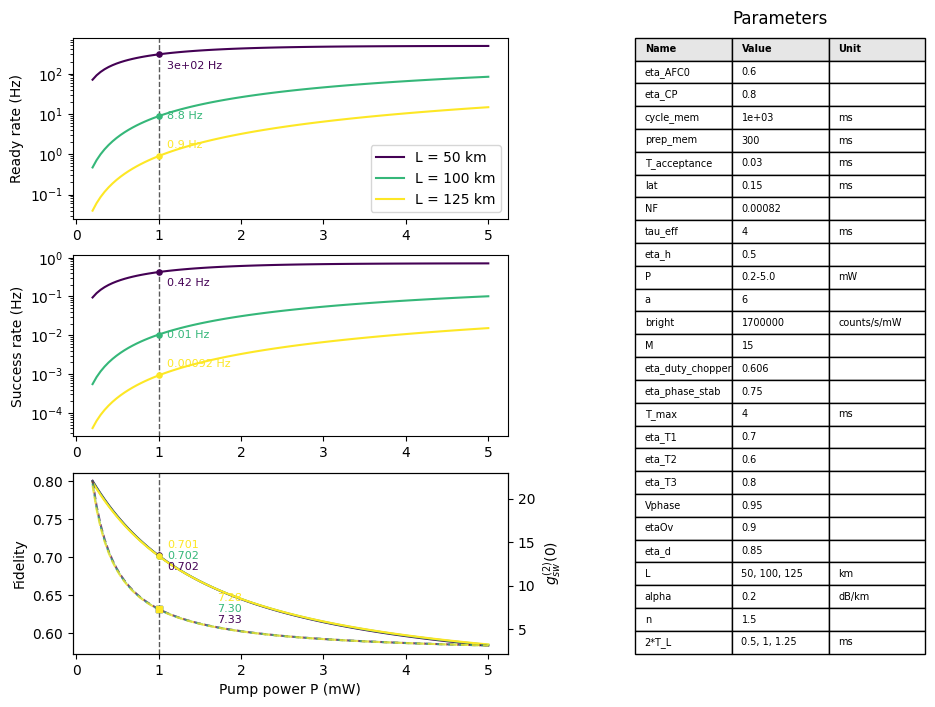

In [230]:
L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))
P_marker = 1
P_scan = np.linspace(0.2, 5, 100)

table_params = params.copy()
table_params["P"] = f"{P_scan[0]:.1f}-{P_scan[-1]:.1f}"
table_params["L"] = ", ".join(str(L) for L in L_scan)
table_params["2*T_L"] = ", ".join(f"{2 * L * params['n'] / params['c'] * 1e3:.3g}" for L in L_scan)
table_params.pop("c", None)
time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "Rid0": "Hz/mW",
    "T_max": "ms",
    "L": "km",
    "alpha": "dB/km",
    "T_L": "ms",
    "2*T_L": "ms",
}
table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])


fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 2], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax3_g2 = ax3.twinx()
ax_table = fig.add_subplot(gs[:, 1])
ax_table.axis("off")

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    # Scan the pump power
    params["L"] = L
    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []
    g2_sw_scan = []

    for P_now in P_scan:
        params["P"] = P_now
        mylink = DoubleChainLink(params, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        g2_sw_scan.append(mylink.g2_sw(0))


    ready_at_marker = np.interp(P_marker, P_scan, Gamma_ready_scan)
    succ_at_marker = np.interp(P_marker, P_scan, Gamma_succ_scan)
    fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
    g2_sw_at_marker = np.interp(P_marker, P_scan, g2_sw_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    ax1.plot(P_scan, Gamma_ready_scan, color = color, label=f"L = {L} km")
    ax1.scatter(P_marker, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel('Ready rate (Hz)')

    ax2.plot(P_scan, Gamma_succ_scan, color = color, label=f"L = {L} km")
    ax2.scatter(P_marker, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel('Success rate (Hz)')

    ax3.plot(P_scan, F_scan, color = color)
    ax3_g2.plot(P_scan, g2_sw_scan, color=color, linestyle="--", alpha=0.75)
    ax3.scatter(P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3_g2.scatter(P_marker, g2_sw_at_marker, color=color, s=14, marker="s", zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3_g2.annotate(f"{g2_sw_at_marker:.2f}", xy=(P_marker, g2_sw_at_marker), xytext=(42, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel('Pump power P (mW)')
    ax3.set_ylabel('Fidelity')
    ax3_g2.set_ylabel(r"$g^{(2)}_{sw}(0)$")
ax1.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax1.legend()
ax1.set_yscale('log')
ax2.set_yscale('log')
param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(7)
param_table.scale(1, 1.15)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)
#plt.tight_layout()
plt.show()

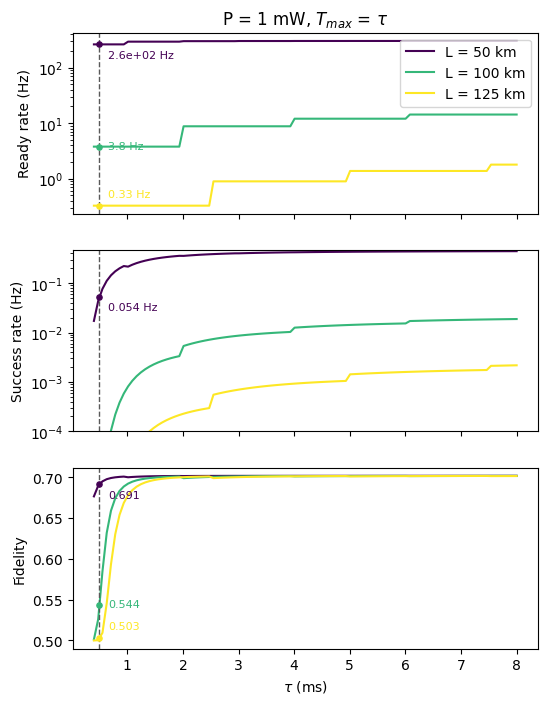

In [231]:
L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))

P_fixed = P_marker
tau_eff_scan = np.linspace(0.4e-3, 8e-3, 100)
tau_eff_scan_ms = tau_eff_scan * 1e3
tau_eff_marker_ms = 0.5

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 8))

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    tau_params = params.copy()
    tau_params["L"] = L
    tau_params["P"] = P_fixed

    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []

    for tau_eff_now in tau_eff_scan:
        tau_params["tau_eff"] = tau_eff_now
        mylink = DoubleChainLink(tau_params, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    ready_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_ready_scan)
    succ_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_succ_scan)
    fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    ax1.plot(tau_eff_scan_ms, Gamma_ready_scan, color=color, label=f"L = {L} km")
    ax1.scatter(tau_eff_marker_ms, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel("Ready rate (Hz)")

    ax2.plot(tau_eff_scan_ms, Gamma_succ_scan, color=color, label=f"L = {L} km")
    ax2.scatter(tau_eff_marker_ms, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel("Success rate (Hz)")

    ax3.plot(tau_eff_scan_ms, F_scan, color=color)
    ax3.scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel(r"$\tau$ (ms)")
    ax3.set_ylabel("Fidelity")

ax1.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax2.set_ylim(bottom=1e-4)
ax1.legend()
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_title(f"P = {P_fixed:g} mW, $T_{{max}}$ = $\\tau$")
plt.show()

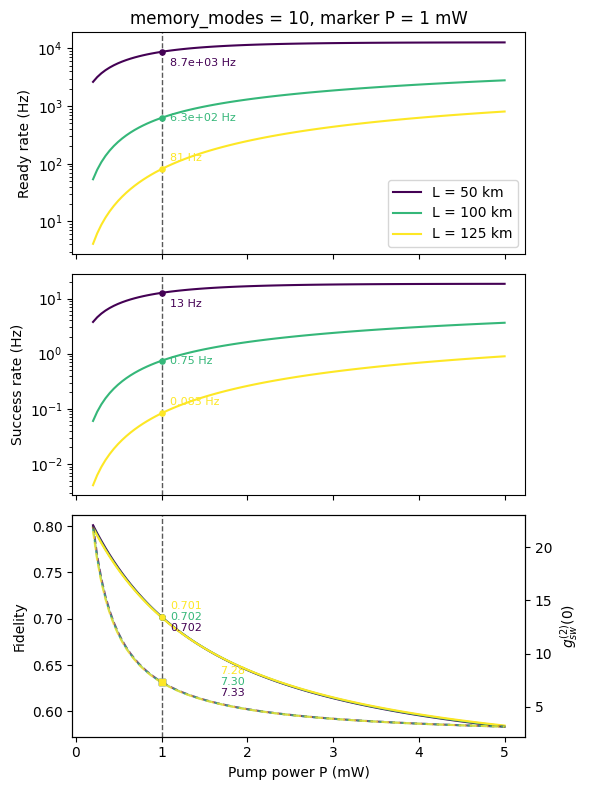

In [232]:
memory_modes_to_plot = 10

L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))

P_marker = 1
P_scan = np.linspace(0.2, 5, 100)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 8))
ax3_g2 = ax3.twinx()

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    scan_params = params.copy()
    scan_params["L"] = L

    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []
    g2_sw_scan = []

    for P_now in P_scan:
        scan_params["P"] = P_now
        mylink = DoubleChainLink(scan_params, memory_modes=memory_modes_to_plot, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        g2_sw_scan.append(mylink.g2_sw(0))

    ready_at_marker = np.interp(P_marker, P_scan, Gamma_ready_scan)
    succ_at_marker = np.interp(P_marker, P_scan, Gamma_succ_scan)
    fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
    g2_sw_at_marker = np.interp(P_marker, P_scan, g2_sw_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    ax1.plot(P_scan, Gamma_ready_scan, color=color, label=f"L = {L} km")
    ax1.scatter(P_marker, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel("Ready rate (Hz)")

    ax2.plot(P_scan, Gamma_succ_scan, color=color, label=f"L = {L} km")
    ax2.scatter(P_marker, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel("Success rate (Hz)")

    ax3.plot(P_scan, F_scan, color=color)
    ax3_g2.plot(P_scan, g2_sw_scan, color=color, linestyle="--", alpha=0.75)
    ax3.scatter(P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3_g2.scatter(P_marker, g2_sw_at_marker, color=color, s=14, marker="s", zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3_g2.annotate(f"{g2_sw_at_marker:.2f}", xy=(P_marker, g2_sw_at_marker), xytext=(42, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel("Pump power P (mW)")
    ax3.set_ylabel("Fidelity")
    ax3_g2.set_ylabel(r"$g^{(2)}_{sw}(0)$")

ax1.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax1.legend()
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_title(f"memory_modes = {memory_modes_to_plot}, marker P = {P_marker:g} mW")
plt.tight_layout()
plt.show()

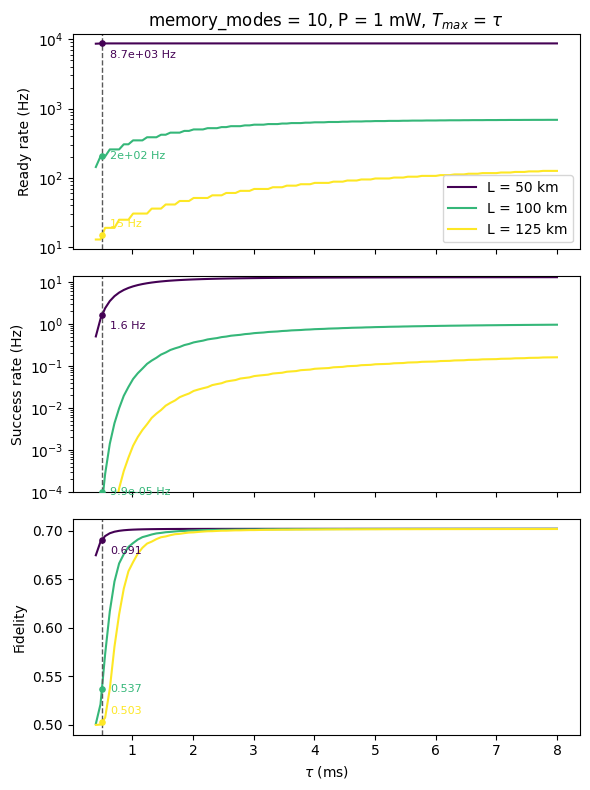

In [233]:
memory_modes_to_plot = 10

L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))

P_fixed = P_marker
tau_eff_scan = np.linspace(0.4e-3, 8e-3, 100)
tau_eff_scan_ms = tau_eff_scan * 1e3
tau_eff_marker_ms = 0.5

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 8))

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    tau_params = params.copy()
    tau_params["L"] = L
    tau_params["P"] = P_fixed

    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []

    for tau_eff_now in tau_eff_scan:
        tau_params["tau_eff"] = tau_eff_now
        mylink = DoubleChainLink(tau_params, memory_modes=memory_modes_to_plot, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    ready_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_ready_scan)
    succ_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_succ_scan)
    fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    ax1.plot(tau_eff_scan_ms, Gamma_ready_scan, color=color, label=f"L = {L} km")
    ax1.scatter(tau_eff_marker_ms, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel("Ready rate (Hz)")

    ax2.plot(tau_eff_scan_ms, Gamma_succ_scan, color=color, label=f"L = {L} km")
    ax2.scatter(tau_eff_marker_ms, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel("Success rate (Hz)")

    ax3.plot(tau_eff_scan_ms, F_scan, color=color)
    ax3.scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel(r"$\tau$ (ms)")
    ax3.set_ylabel("Fidelity")

ax1.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax2.set_ylim(bottom=1e-4)
ax1.legend()
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_title(f"memory_modes = {memory_modes_to_plot}, P = {P_fixed:g} mW, $T_{{max}}$ = $\\tau$")
plt.tight_layout()
plt.show()

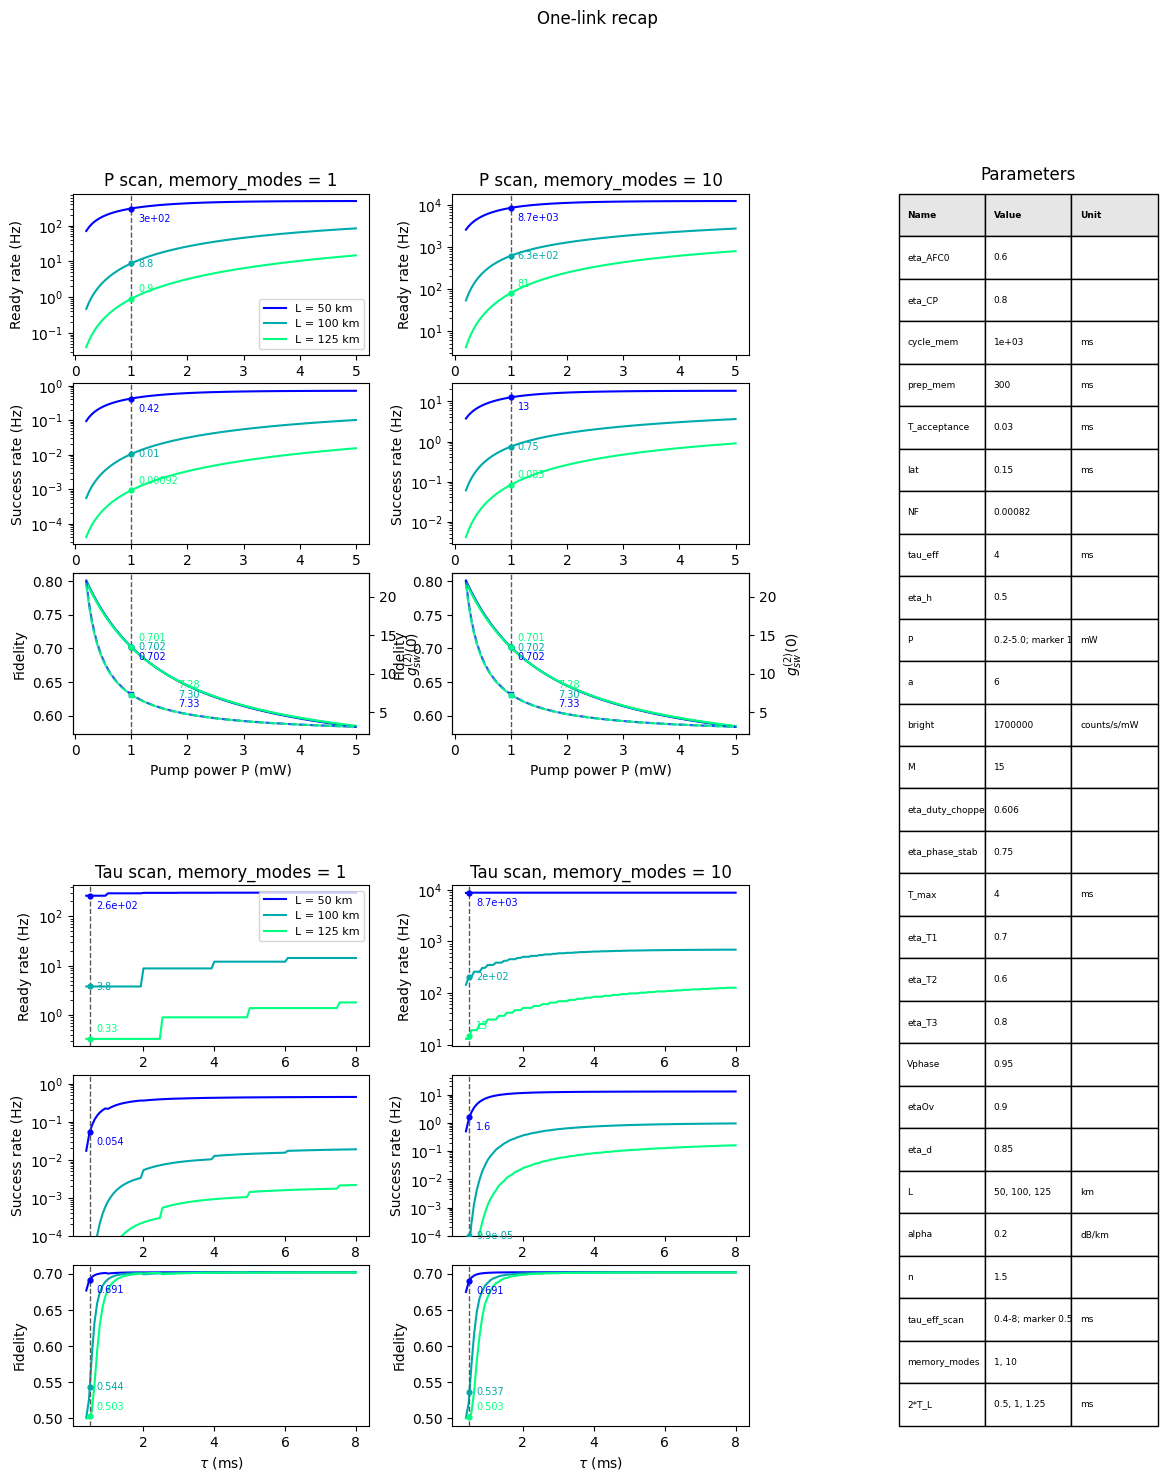

<Figure size 640x480 with 0 Axes>

In [234]:
recap_memory_modes = [1, 10]

L_scan = [50, 100, 125]
cmap = plt.cm.winter
norm = plt.Normalize(min(L_scan), max(L_scan))

P_marker = 1
P_scan = np.linspace(0.2, 5, 100)
P_fixed = P_marker

tau_eff_scan = np.linspace(0.4e-3, 8e-3, 100)
tau_eff_scan_ms = tau_eff_scan * 1e3
tau_eff_marker_ms = 0.5

fig = plt.figure(figsize=(14, 16))
outer_gs = fig.add_gridspec(2, 2, width_ratios=[2.35, 0.9], height_ratios=[1, 1], wspace=0.32, hspace=0.28)
p_gs = outer_gs[0, 0].subgridspec(3, 2, wspace=0.28, hspace=0.18)
tau_gs = outer_gs[1, 0].subgridspec(3, 2, wspace=0.28, hspace=0.18)

p_axes = [[fig.add_subplot(p_gs[row, col]) for col in range(2)] for row in range(3)]
tau_axes = [[fig.add_subplot(tau_gs[row, col]) for col in range(2)] for row in range(3)]
p_g2_axes = [p_axes[2][col].twinx() for col in range(2)]

ax_table = fig.add_subplot(outer_gs[:, 1])
ax_table.axis("off")

for col, memory_modes_now in enumerate(recap_memory_modes):
    for i, L in enumerate(L_scan):
        color = cmap(norm(L))
        Gamma_ready_scan = []
        Gamma_succ_scan = []
        F_scan = []
        g2_sw_scan = []

        for P_now in P_scan:
            scan_params = params.copy()
            scan_params["L"] = L
            scan_params["P"] = P_now
            mylink = DoubleChainLink(scan_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            Gamma_ready_scan.append(mylink.Gamma_ready)
            Gamma_succ_scan.append(mylink.Gamma_succ)
            F_scan.append(mylink.fidelity)
            g2_sw_scan.append(mylink.g2_sw(0))

        ready_at_marker = np.interp(P_marker, P_scan, Gamma_ready_scan)
        succ_at_marker = np.interp(P_marker, P_scan, Gamma_succ_scan)
        fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
        g2_sw_at_marker = np.interp(P_marker, P_scan, g2_sw_scan)
        label_offset = 7 * (i - (len(L_scan) - 1) / 2)

        p_axes[0][col].plot(P_scan, Gamma_ready_scan, color=color, label=f"L = {L} km")
        p_axes[0][col].scatter(P_marker, ready_at_marker, color=color, s=12, zorder=3)
        p_axes[0][col].annotate(f"{ready_at_marker:.2g}", xy=(P_marker, ready_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        p_axes[1][col].plot(P_scan, Gamma_succ_scan, color=color, label=f"L = {L} km")
        p_axes[1][col].scatter(P_marker, succ_at_marker, color=color, s=12, zorder=3)
        p_axes[1][col].annotate(f"{succ_at_marker:.2g}", xy=(P_marker, succ_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        p_axes[2][col].plot(P_scan, F_scan, color=color)
        p_g2_axes[col].plot(P_scan, g2_sw_scan, color=color, linestyle="--", alpha=0.75)
        p_axes[2][col].scatter(P_marker, fidelity_at_marker, color=color, s=12, zorder=3)
        p_g2_axes[col].scatter(P_marker, g2_sw_at_marker, color=color, s=12, marker="s", zorder=3)
        p_axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
        p_g2_axes[col].annotate(f"{g2_sw_at_marker:.2f}", xy=(P_marker, g2_sw_at_marker), xytext=(34, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

for col, memory_modes_now in enumerate(recap_memory_modes):
    for i, L in enumerate(L_scan):
        color = cmap(norm(L))
        Gamma_ready_scan = []
        Gamma_succ_scan = []
        F_scan = []

        for tau_eff_now in tau_eff_scan:
            tau_params = params.copy()
            tau_params["L"] = L
            tau_params["P"] = P_fixed
            tau_params["tau_eff"] = tau_eff_now
            mylink = DoubleChainLink(tau_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            Gamma_ready_scan.append(mylink.Gamma_ready)
            Gamma_succ_scan.append(mylink.Gamma_succ)
            F_scan.append(mylink.fidelity)

        ready_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_ready_scan)
        succ_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_succ_scan)
        fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)
        label_offset = 7 * (i - (len(L_scan) - 1) / 2)

        tau_axes[0][col].plot(tau_eff_scan_ms, Gamma_ready_scan, color=color, label=f"L = {L} km")
        tau_axes[0][col].scatter(tau_eff_marker_ms, ready_at_marker, color=color, s=12, zorder=3)
        tau_axes[0][col].annotate(f"{ready_at_marker:.2g}", xy=(tau_eff_marker_ms, ready_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        tau_axes[1][col].plot(tau_eff_scan_ms, Gamma_succ_scan, color=color, label=f"L = {L} km")
        tau_axes[1][col].scatter(tau_eff_marker_ms, succ_at_marker, color=color, s=12, zorder=3)
        tau_axes[1][col].annotate(f"{succ_at_marker:.2g}", xy=(tau_eff_marker_ms, succ_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        tau_axes[2][col].plot(tau_eff_scan_ms, F_scan, color=color)
        tau_axes[2][col].scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=12, zorder=3)
        tau_axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

for col, memory_modes_now in enumerate(recap_memory_modes):
    p_axes[0][col].set_title(f"P scan, memory_modes = {memory_modes_now}")
    tau_axes[0][col].set_title(f"Tau scan, memory_modes = {memory_modes_now}")
    p_axes[2][col].set_xlabel("Pump power P (mW)")
    tau_axes[2][col].set_xlabel(r"$\tau$ (ms)")
    p_axes[0][col].set_yscale("log")
    p_axes[1][col].set_yscale("log")
    tau_axes[0][col].set_yscale("log")
    tau_axes[1][col].set_yscale("log")
    tau_axes[1][col].set_ylim(bottom=1e-4)
    for row in range(3):
        p_axes[row][col].axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
        tau_axes[row][col].axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)

for axes_group in (p_axes, tau_axes):
    for col in range(2):
        axes_group[0][col].set_ylabel("Ready rate (Hz)")
        axes_group[1][col].set_ylabel("Success rate (Hz)")
        axes_group[2][col].set_ylabel("Fidelity")

for ax in p_g2_axes:
    ax.set_ylabel(r"$g^{(2)}_{sw}(0)$")

p_axes[0][0].legend(fontsize=8)
tau_axes[0][0].legend(fontsize=8)

table_params = params.copy()
table_params["P"] = f"{P_scan[0]:.1f}-{P_scan[-1]:.1f}; marker {P_marker:g}"
table_params["tau_eff_scan"] = f"{tau_eff_scan_ms[0]:.3g}-{tau_eff_scan_ms[-1]:.3g}; marker {tau_eff_marker_ms:g}"
table_params["L"] = ", ".join(str(L) for L in L_scan)
table_params["memory_modes"] = ", ".join(str(memory_modes) for memory_modes in recap_memory_modes)
table_params["2*T_L"] = ", ".join(f"{2 * L * params['n'] / params['c'] * 1e3:.3g}" for L in L_scan)
table_params.pop("c", None)

time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "tau_eff_scan": "ms",
    "T_max": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "L": "km",
    "alpha": "dB/km",
    "n": "",
    "2*T_L": "ms",
    "memory_modes": "",
}
table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])

param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(6.5)
param_table.scale(1, 1.1)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)

fig.suptitle("One-link recap", y=0.995)
plt.show()
plt.tight_layout()

In [235]:
class DoubleChainDoubleLink:
    def __init__(self, params, memory_modes=1, print_rate=False):
        self.params = SimpleNamespace(**params)
        self.calculate_params()
        self.memory_modes = memory_modes
        self.print_rate = print_rate

    def calculate_params(self):
        """Calculate parameters that depend on other parameters."""
        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.Rid0 = 2 * self.params.bright / self.params.M
        self.params.g2 = 1 + self.params.a / self.params.P
        self.params.T_max = self.params.tau_eff * 0.5
        self.params.eta_path = self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3
        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c
        if not hasattr(self.params, "eta_BSM"):
            self.params.eta_BSM = 0.5
        if not hasattr(self.params, "V_BSM"):
            self.params.V_BSM = 1.0

    # time dependent functions

    def efficiency(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw(self, t):
        """Cross-correlation function as a function of storage time."""
        return 1 + self.params.eta_h * self.efficiency(t) * self.params.eta_path * self.params.eta_d  / (self.params.eta_h * self.efficiency(t) * self.params.eta_path * self.params.eta_d / self.params.g2 + self.params.NF)

    def V(self, t):
        """Visibility as a function of storage time."""
        return (self.g2_sw(t) - 1) / (self.g2_sw(t) + 1) * self.params.Vphase * self.params.etaOv

    def p10(self, t):
        """Probability to detect a photon on the left of one elementary link, and no photon on the right, conditioned on idler detection."""
        return self.efficiency(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2

    def p11(self, t):
        """Probability to detect a photon on both sides of one elementary link, conditioned on idler detection."""
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def q_pop(self, t):
        """Part of the density matrix population in the |10><10| and |01><01| subspace, conditioned on idler detection."""
        return (2 * self.p10(t))/(2 * self.p10(t) + self.p11(t))

    def w_(self, k):
        return self.p**2 if k == 0 else 2 * self.p**2 * self.q**k

    def W_j_(self, j):
        return sum(self.w_(k) for k in range(int(self.N) - j + 1))

    def D_j_(self, j):
        return sum(self.w_(k) * self.efficiency(2*j*self.params.T_L) * self.efficiency(2*(j+k)*self.params.T_L) for k in range(int(self.N) - j + 1))

    def P_j_(self, j):
        return sum(self.w_(k) * self.efficiency(2*j*self.params.T_L) * self.efficiency(2*(j+k)*self.params.T_L) * self.q_pop(2*j*self.params.T_L) * self.q_pop(2*(j+k)*self.params.T_L) for k in range(int(self.N) - j + 1))

    def C_j_(self, j):
        return sum(self.w_(k) * self.efficiency(2*j*self.params.T_L) * self.efficiency(2*(j+k)*self.params.T_L) * self.q_pop(2*j*self.params.T_L) * self.q_pop(2*(j+k)*self.params.T_L) * self.V(2*j*self.params.T_L) * self.V(2*(j+k)*self.params.T_L) for k in range(int(self.N) - j + 1))

    def get_rates(self):
        self.N = int(np.floor(self.params.T_max / 2 / self.params.T_L))                  # Number of rounds before giving up
        self.Gamma_1 = self.params.Rid0 * self.params.P * self.params.fib * self.params.eta_d * 2     # heralding rate of idlers in central station
        self.p = 1 - np.exp(- self.Gamma_1 * self.params.T_acceptance)       # Probability of at least one heralding event in T_acceptance
        self.q = 1 - self.p                                                              # Probability of no heralding event in T_acceptance
        self.Delta = 2 * self.params.T_L
        self.duty = self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

        if self.memory_modes == 1:
            self.p_ready_1 = self.p**2 + 2*self.p*self.q*(1 - self.q**self.N)
            self.p_ready_conditioned_non_empty_1 = self.p_ready_1 / (1 - self.q**2)
            self.Gamma_ready_1_raw = self.p_ready_1 / (1 + 2*self.q*(1 - self.q**self.N)) / self.Delta

            self.rho = min(self.Gamma_ready_1_raw * self.Delta, 1)
            self.Q = 1 - self.rho
            self.A = 0 if self.p_ready_1 == 0 else (self.p**2 * (1 - self.Q**self.N) + sum(2*self.p**2*self.q**k * (1 - self.Q**(self.N-k)) for k in range(1, self.N + 1))) / self.p_ready_1

            self.p_ready_conditioned_non_empty = (self.rho**2 + 2*self.rho*self.Q*self.A) / (1 - self.Q**2)
            self.n_cycle = (1 + 2*self.Q*self.A) / (1 - self.Q**2)
            self.T_cycle = self.n_cycle * self.Delta + self.p_ready_conditioned_non_empty*self.params.lat

            # Final ready rate
            self.Gamma_ready = self.p_ready_conditioned_non_empty / self.T_cycle * self.duty

            # probability to have successfuly detected all the photons given a ready event
            den_sync = self.W_j_(0)**2 + 2*sum(self.Q**j * self.W_j_(j) * self.W_j_(0) for j in range(1, self.N + 1))
            eta_sync = self.D_j_(0)**2 + 2*sum(self.Q**j * self.D_j_(j) * self.D_j_(0) for j in range(1, self.N + 1))
            self.eta_avg = np.nan if den_sync == 0 else eta_sync / den_sync
            self.p_succ = self.params.eta_BSM * self.params.eta_h**4 * self.params.eta_path**4 * self.params.eta_d**4 / 4 * self.eta_avg

            # Overall success rate
            self.Gamma_succ = self.Gamma_ready * self.p_succ
        else:
            self.age_step = 2 * self.params.T_L / self.memory_modes
            self.K = max(1, int(np.ceil(self.params.T_max / self.age_step)))
            self.lambda_M = self.memory_modes * self.p / (2 * self.params.T_L)
            self.Gamma_ready = 4 * self.lambda_M * (1 - self.q**self.K)**3 * self.duty

            # probability to have successfuly detected all the photons given a ready event
            den_ready = 1 - self.q**self.K
            eta_stored = sum(self.p * self.q**j * self.efficiency(j * self.age_step) for j in range(self.K)) / den_ready
            self.eta_avg = self.efficiency(0) * eta_stored**3
            self.p_succ = self.params.eta_BSM * self.params.eta_h**4 * self.params.eta_path**4 * self.params.eta_d**4 / 4 * self.eta_avg
            self.Gamma_succ = self.Gamma_ready * self.p_succ

        if self.print_rate:
            print(f"Ready rate: {self.Gamma_ready:.2f} Hz")
            print(f"Success rate: {self.Gamma_succ:.4e} Hz")
            print(f"Number of rounds before giving up: {int(self.N)}")

    def get_fidelity(self):
        if not hasattr(self, "Gamma_succ"):
            self.get_rates()

        if self.memory_modes == 1:
            D0 = self.D_j_(0)
            P0 = self.P_j_(0)
            C0 = self.C_j_(0)

            num = P0**2 + self.params.V_BSM*C0**2 + 2*sum(self.Q**j * (self.P_j_(j)*P0 + self.params.V_BSM*self.C_j_(j)*C0) for j in range(1, self.N + 1))
            den = D0**2 + 2*sum(self.Q**j * self.D_j_(j)*D0 for j in range(1, self.N + 1))
            self.fidelity = np.nan if den == 0 else num / (2 * den)
        else:
            B0 = sum(self.p * self.q**j * self.efficiency(j * self.age_step) for j in range(self.K))
            Bq = sum(self.p * self.q**j * self.efficiency(j * self.age_step) * self.q_pop(j * self.age_step) for j in range(self.K))
            BqV = sum(self.p * self.q**j * self.efficiency(j * self.age_step) * self.q_pop(j * self.age_step) * self.V(j * self.age_step) for j in range(self.K))
            self.fidelity = np.nan if B0 == 0 else self.q_pop(0) / 2 * (Bq**3 + self.params.V_BSM*self.V(0)*BqV**3) / B0**3

        if self.print_rate:
            print(f"Fidelity: {self.fidelity:.4f}")


In [236]:
my_doublelink = DoubleChainDoubleLink(params, print_rate=True)
my_doublelink.get_rates()
my_doublelink.get_fidelity()


Ready rate: 1.41 Hz
Success rate: 6.5604e-07 Hz
Number of rounds before giving up: 1
Fidelity: 0.4989


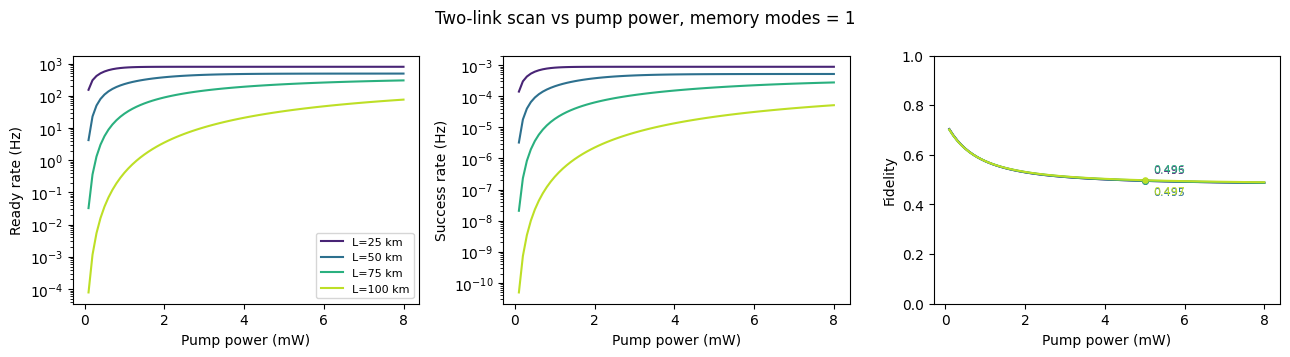

In [237]:
P_scan = np.linspace(0.1, 8, 80)
L_scan = [25, 50, 75, 100]
P_marker = params["P"]
memory_modes_to_plot = 1

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(L_scan)))

for i, L_now in enumerate(L_scan):
    ready_scan = []
    success_scan = []
    F_scan = []
    for P_now in P_scan:
        scan_params = params.copy()
        scan_params["P"] = P_now
        scan_params["L"] = L_now
        mylink = DoubleChainDoubleLink(scan_params, memory_modes=memory_modes_to_plot, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        ready_scan.append(mylink.Gamma_ready)
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    color = colors[i]
    label_offset = (-1)**i * 8
    fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)

    ax1.plot(P_scan, ready_scan, color=color, label=f"L={L_now} km")
    ax2.plot(P_scan, success_scan, color=color)
    ax3.plot(P_scan, F_scan, color=color)
    ax3.scatter(P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

ax1.set_xlabel("Pump power (mW)")
ax1.set_ylabel("Ready rate (Hz)")
ax1.set_yscale("log")
ax1.legend(fontsize=8)

ax2.set_xlabel("Pump power (mW)")
ax2.set_ylabel("Success rate (Hz)")
ax2.set_yscale("log")

ax3.set_xlabel("Pump power (mW)")
ax3.set_ylabel("Fidelity")
ax3.set_ylim(0, 1)

fig.suptitle(f"Two-link scan vs pump power, memory modes = {memory_modes_to_plot}")
plt.tight_layout()
plt.show()


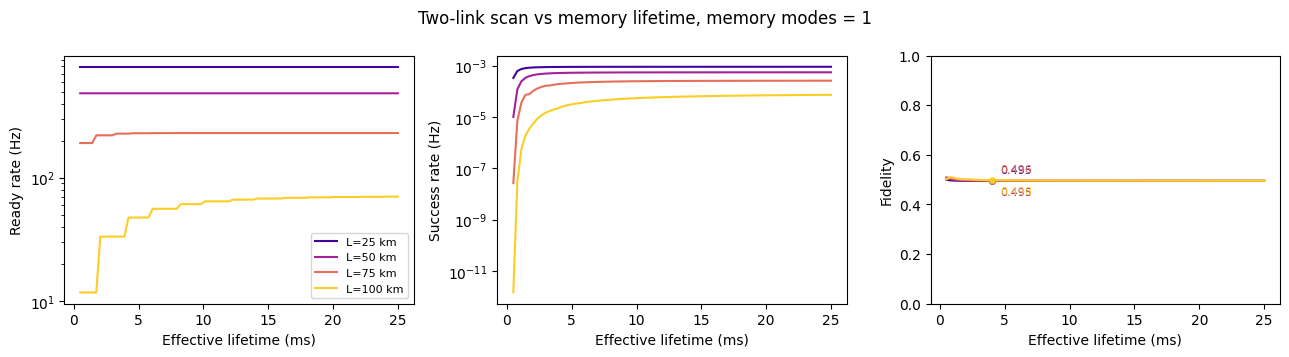

In [238]:
tau_eff_scan_ms = np.linspace(0.5, 25, 80)
L_scan = [25, 50, 75, 100]
tau_eff_marker_ms = params["tau_eff"] * 1e3
memory_modes_to_plot = 1

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(L_scan)))

for i, L_now in enumerate(L_scan):
    ready_scan = []
    success_scan = []
    F_scan = []
    for tau_eff_now_ms in tau_eff_scan_ms:
        tau_params = params.copy()
        tau_params["tau_eff"] = tau_eff_now_ms * 1e-3
        tau_params["L"] = L_now
        mylink = DoubleChainDoubleLink(tau_params, memory_modes=memory_modes_to_plot, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        ready_scan.append(mylink.Gamma_ready)
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    color = colors[i]
    label_offset = (-1)**i * 8
    fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)

    ax1.plot(tau_eff_scan_ms, ready_scan, color=color, label=f"L={L_now} km")
    ax2.plot(tau_eff_scan_ms, success_scan, color=color)
    ax3.plot(tau_eff_scan_ms, F_scan, color=color)
    ax3.scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

ax1.set_xlabel("Effective lifetime (ms)")
ax1.set_ylabel("Ready rate (Hz)")
ax1.set_yscale("log")
ax1.legend(fontsize=8)

ax2.set_xlabel("Effective lifetime (ms)")
ax2.set_ylabel("Success rate (Hz)")
ax2.set_yscale("log")

ax3.set_xlabel("Effective lifetime (ms)")
ax3.set_ylabel("Fidelity")
ax3.set_ylim(0, 1)

fig.suptitle(f"Two-link scan vs memory lifetime, memory modes = {memory_modes_to_plot}")
plt.tight_layout()
plt.show()


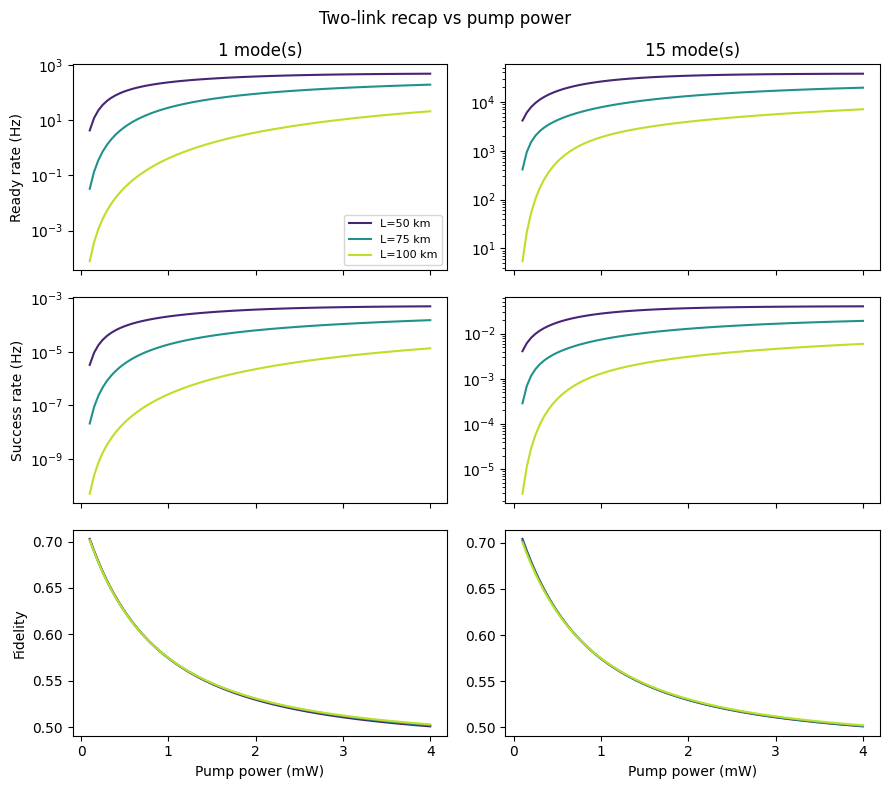

In [242]:
double_recap_memory_modes = [1, 15]
P_scan = np.linspace(0.1, 4, 80)
L_scan = [50, 75, 100]

fig, axes = plt.subplots(3, len(double_recap_memory_modes), figsize=(9, 8), sharex="col")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(L_scan)))

for col, memory_modes_now in enumerate(double_recap_memory_modes):
    for i, L_now in enumerate(L_scan):
        ready_scan = []
        success_scan = []
        F_scan = []
        for P_now in P_scan:
            scan_params = params.copy()
            scan_params["P"] = P_now
            scan_params["L"] = L_now
            mylink = DoubleChainDoubleLink(scan_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            ready_scan.append(mylink.Gamma_ready)
            success_scan.append(mylink.Gamma_succ)
            F_scan.append(mylink.fidelity)

        color = colors[i]
        axes[0][col].plot(P_scan, ready_scan, color=color, label=f"L={L_now} km")
        axes[1][col].plot(P_scan, success_scan, color=color)
        axes[2][col].plot(P_scan, F_scan, color=color)

    axes[0][col].set_title(f"{memory_modes_now} mode(s)")
    axes[0][col].set_yscale("log")
    axes[1][col].set_yscale("log")
    axes[2][col].set_xlabel("Pump power (mW)")

axes[0][0].set_ylabel("Ready rate (Hz)")
axes[1][0].set_ylabel("Success rate (Hz)")
axes[2][0].set_ylabel("Fidelity")
axes[0][0].legend(fontsize=8)
fig.suptitle("Two-link recap vs pump power")
plt.tight_layout()
plt.show()
